<a href="https://colab.research.google.com/github/Matheus0820/Aprendizado-de-Maquina/blob/main/unidade01/codes/Aplicando_SOM_na_base_de_dados_da_Mega_Sena.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aplicando SOM na base de dados da Mega-Sena - Tentando prever padrão com algoritmo SOM

Aprendizado de Máquina 26.1

**Aluno:** Matheus Ramos Ferreira da Silva


## Importando dados

In [15]:
# Biblioteca
import pandas as pd

url = 'https://raw.githubusercontent.com/Matheus0820/Aprendizado-de-Maquina/refs/heads/main/unidade01/datasets/sorteios.csv'

df = pd.read_csv(url)
df.head()

,Id,Concurso,Data Sorteio,1ª Dezena,2ª Dezena,3ª Dezena,4ª Dezena,5ª Dezena,6ª Dezena,Arrecadacao_Total,...,Rateio_Sena,Ganhadores_Quina,Rateio_Quina,Ganhadores_Quadra,Rateio_Quadra,Acumulado,Valor_Acumulado,Estimativa_Prêmio,Acumulado_Mega_da_Virada,Unnamed: 22
0,1,1,11/03/1996,41,5,4,52,30,33,"0,00",...,"0,00",17,"39.158,92",2016,"330,21",SIM,"1.714.650,23","0,00","0,00",NaN
1,2,2,18/03/1996,9,39,37,49,43,41,"0,00",...,"2.307.162,23",65,"14.424,02",4488,"208,91",NÃO,"0,00","0,00","0,00",NaN
2,3,3,25/03/1996,36,30,10,11,29,47,"0,00",...,"391.192,51",62,"10.515,93",4261,"153,01",NÃO,"0,00","0,00","0,00",NaN
3,4,3,25/03/1996,36,30,10,11,29,47,"0,00",...,"391.192,51",62,"10.515,93",4261,"153,01",NÃO,"0,00","0,00","0,00",NaN
4,5,4,01/04/1996,6,59,42,27,1,5,"0,00",...,"0,00",39,"15.322,24",3311,"180,48",SIM,"717.080,75","0,00","0,00",NaN


## Selecionando features que serão utilizadas
As features que serão utilizada é as seguintes:
- 1ª Dezena;
- 2ª Dezena;
- 3ª Dezena;
- 4ª Dezena;
- 5ª Dezena;
- 6ª Dezena.

In [5]:
# Definindo os dados que seram usado na classificação do algoritmo
features_selected = ['1ª Dezena', '2ª Dezena', '3ª Dezena', '4ª Dezena', '5ª Dezena', '6ª Dezena']
X = df[features_selected].values

# Printando 5 primeiras linhas
print(X[:5])

[[41  5  4 52 30 33]
 [ 9 39 37 49 43 41]
 [36 30 10 11 29 47]
 [36 30 10 11 29 47]
 [ 6 59 42 27  1  5]]


## Treinamento

In [6]:
# Instalado o Minisom
!pip install minisom

  Preparing metadata (setup.py) ... done
  Created wheel for minisom: filename=MiniSom-2.3.6-py3-none-any.whl size=13083 sha256=72b561a401f36895000edc376b6e6b13035ab4ad47c536817b654d838753a3d5
  Stored in directory: /root/.cache/pip/wheels/84/35/b8/48b06bd8cae7187916c28a29c6daa9e0ff610647a2dfa62b97
Successfully built minisom


In [7]:
# Número de linhas e colunas
linhas = X.shape[0]
colunas = X.shape[1]

# Mostrando
print(f"Linhas: {linhas}\nColunas: {colunas}")


Linhas: 2278
Colunas: 6


In [8]:
# Treinando o minisom. Utilizando o tamanho x e y para 6

# Biblioteca
from minisom import MiniSom

# Treinando
som = MiniSom(x=6, y=6, input_len=colunas, learning_rate=0.4, sigma=1.0, random_seed=9)
som.train(X, num_iteration=10000)

## Visualizando o treinamento

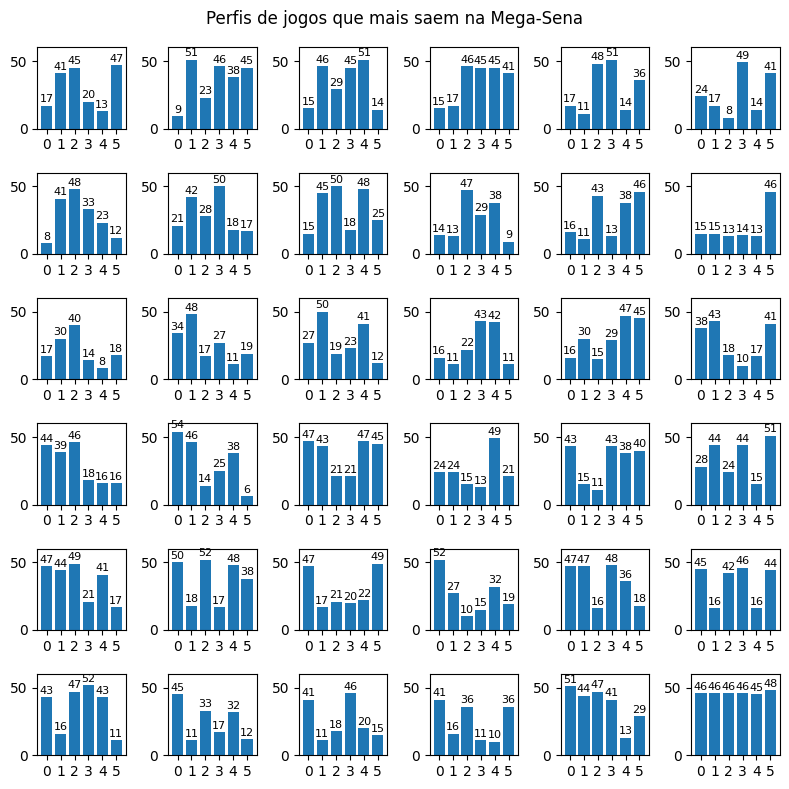

In [21]:
# Pegando os pesos dos neurônios e colocando em um gráfico para ver a distribuição dos perfis de jogo

# Bibliotecas
import matplotlib.pyplot as plt

# Pegando os pesos
pesos = som.get_weights()

# Arredondando pesos - Valor inteiro mais próximo
pesos = pesos.round()

# Gerando gráfico
fig, axes = plt.subplots(nrows=6, ncols=6, figsize=(8, 8))
fig.suptitle('Perfis de jogos que mais saem na Mega-Sena')

for i in range(6):
    for j in range(6):
      weights = pesos[i][j]

      axes[i][j].bar(range(len(weights)), weights)
      axes[i][j].set_xticks(range(len(weights)))
      axes[i][j].set_ylim(0, 60)

      for k, w in enumerate(weights):
          axes[i][j].text(k, w + 1, f'{w:.0f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()